<div align="right">
АС-23-05, Тищенко Кирилл, Вариант №97
</div>

In [5]:
%load_ext autoreload
%autoreload 2
    
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
from scipy.optimize import minimize
from mpl_toolkits.mplot3d import Axes3D

from utils import plot_trajectory, plot_rejection_random_search

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Лабораторная работа №5 "Методы случайного поиска для многомерной минимизации"

$$f(\mathbf{x}) = 194x_1^2 + 376x_1x_2 + 194x_2^2 + 31x_1 - 229x_2 + 4$$

In [2]:
def f(x):
    x1, x2 = x
    return 194 * x1 ** 2 + 376 * x1 * x2 + 194 * x2 ** 2 + 31 * x1 - 229 * x2 + 4

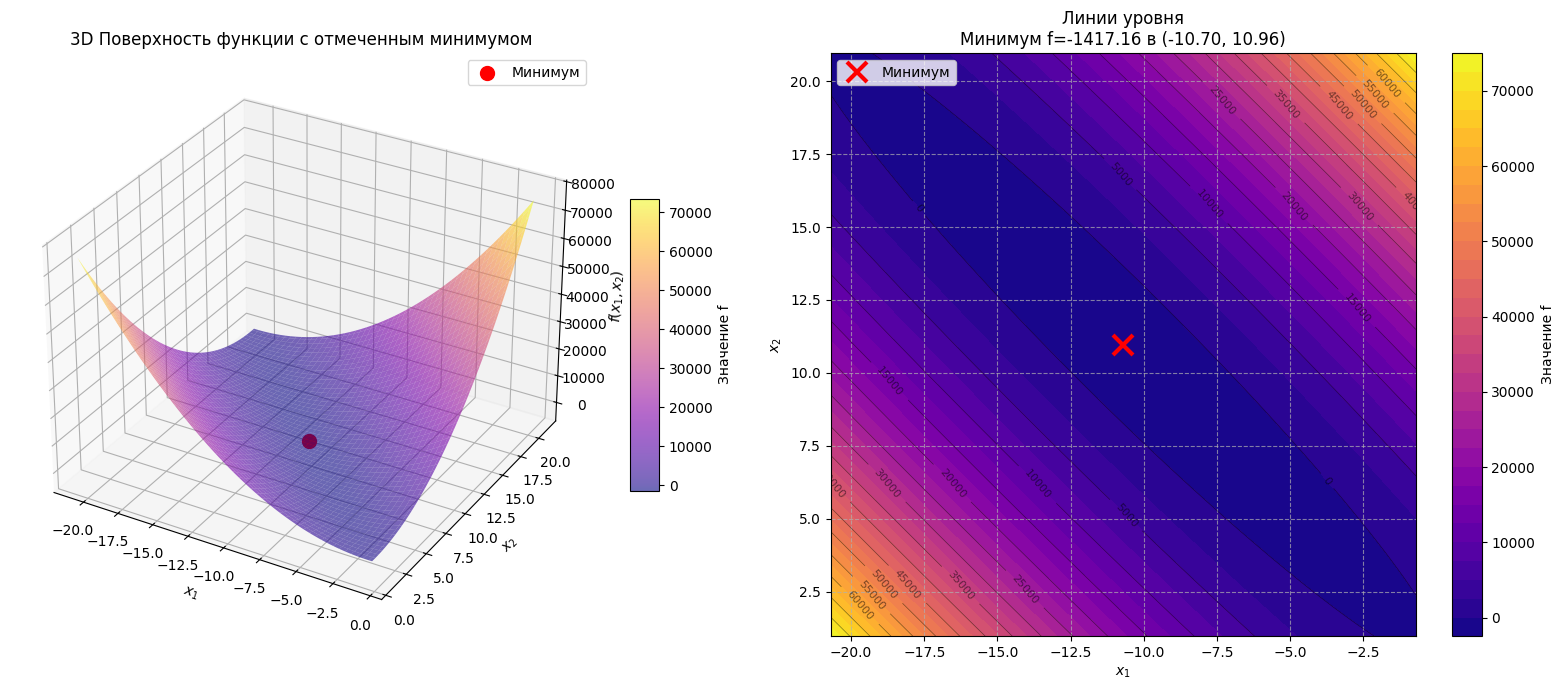

Точка минимума
x1 = -10.704
x2 = 10.963
Значение функции в этой точке: -1417.162


In [21]:
x_min_arr = np.array([-10.7037581, 10.96292084])
f_min_val = -1417.1618673642563

buffer = 10
x1_range = np.linspace(x_min_arr[0] - buffer, x_min_arr[0] + buffer, 100)
x2_range = np.linspace(x_min_arr[1] - buffer, x_min_arr[1] + buffer, 100)

X1, X2 = np.meshgrid(x1_range, x2_range)

def f_mesh(x1, x2):
    return 194*x1**2 + 376*x1*x2 + 194*x2**2 + 31*x1 - 229*x2 + 4

Z = f_mesh(X1, X2)


fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='plasma', edgecolor='none', alpha=0.6)
ax1.scatter(x_min_arr[0], x_min_arr[1], f_min_val, color='red', s=100, label='Минимум')
ax1.set_title('3D Поверхность функции с отмеченным минимумом')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1, x_2)$')
ax1.legend()
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10, label='Значение f')


ax2 = fig.add_subplot(1, 2, 2)
contour_filled = ax2.contourf(X1, X2, Z, levels=30, cmap='plasma')
fig.colorbar(contour_filled, ax=ax2, label='Значение f')
contours = ax2.contour(X1, X2, Z, levels=15, colors='black', alpha=0.5, linewidths=0.5)
ax2.clabel(contours, inline=True, fontsize=8)
ax2.plot(x_min_arr[0], x_min_arr[1], 'rx', markersize=15, markeredgewidth=3, label='Минимум')

ax2.set_title(f'Линии уровня\nМинимум f={f_min_val:.2f} в ({x_min_arr[0]:.2f}, {x_min_arr[1]:.2f})')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

x0 = [0, 0]
res = minimize(f, x0, method='BFGS')

print(f"Точка минимума\nx1 = {res.x[0]:.3f}\nx2 = {res.x[1]:.3f}")
print(f"Значение функции в этой точке: {res.fun:.3f}")

## Адаптивный метод случайного поиска

In [3]:
def adaptive_random_search(f,x0,h0=1.0,alpha=1.2,beta=0.7,max_iter=2000,tol=1e-6,tries=10):
    x=np.array(x0,dtype=float)
    h=h0
    f_x=f(x)
    func_evals=1
    path=[x.copy()]
    for iteration in range(1,max_iter+1):
        improved=False
        for _ in range(tries):
            direction=np.random.randn(len(x))
            direction/=np.linalg.norm(direction)
            x_new=x+h*direction
            f_new=f(x_new)
            func_evals+=1
            if f_new<f_x:
                x=x_new
                f_x=f_new
                h*=alpha
                improved=True
                break
        if not improved:
            h*=beta
        h*=0.995
        path.append(x.copy())
        if h<tol:
            break

    return x,f_x,iteration,func_evals,np.array(path)

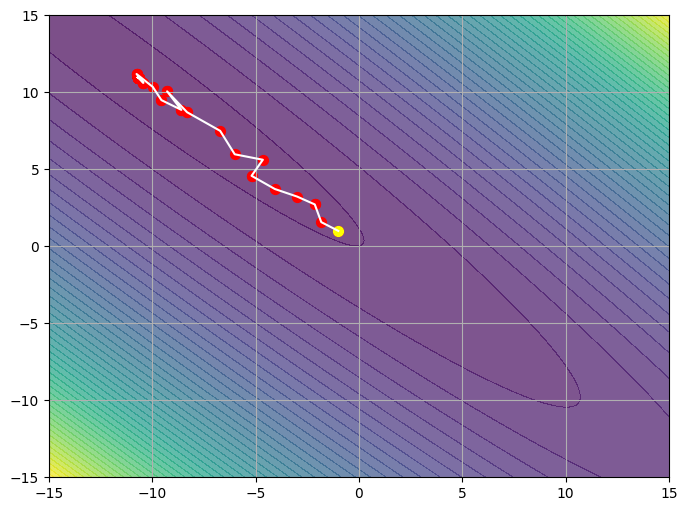

Точка минимума
x1 = -10.704
x2 = 10.963
Значение функции в этой точке: -1417.162
Итерации: 95
Вычисления функции: 734


In [20]:
x0 = [-1, 1]

x, f_x, iteration, func_evals, path = adaptive_random_search(f, x0)

plot_trajectory(f,path)
print("Точка минимума")
print(f"x1 = {x[0]:.3f}")
print(f"x2 = {x[1]:.3f}")
print(f"Значение функции в этой точке: {f_x:.3f}")
print(f"Итерации: {iteration}")
print(f"Вычисления функции: {func_evals}")

##  Mетод случайного поиска с возвратом при неудачном шаге

In [8]:
def random_search_with_rejection(f,x0,alpha=1.0,epsilon=1e-6,gamma=1.5,M=None,max_iter=100000):
    x=np.array(x0,dtype=float)
    n=len(x)
    if M is None:
        M=3*n
    f_x=f(x)
    func_evals=1
    no_improve_global=0
    path=[x.copy()]
    for iteration in range(1,max_iter+1):
        j=1
        improved=False
        while j<=M:
            xi=np.random.uniform(-1,1,size=n)
            norm=np.linalg.norm(xi)
            if norm==0:
                continue
            y=x+alpha*(xi/norm)
            f_y=f(y)
            func_evals+=1
            if f_y<f_x:
                x=y
                f_x=f_y
                alpha=min(alpha*1.1,10.0)
                improved=True
                no_improve_global=0
                path.append(x.copy())
                break
            j+=1
        if not improved:
            alpha=alpha/gamma
            no_improve_global+=1
        if alpha<epsilon:
            break
        if no_improve_global>50:
            break

    return x,f_x,iteration,func_evals,np.array(path)

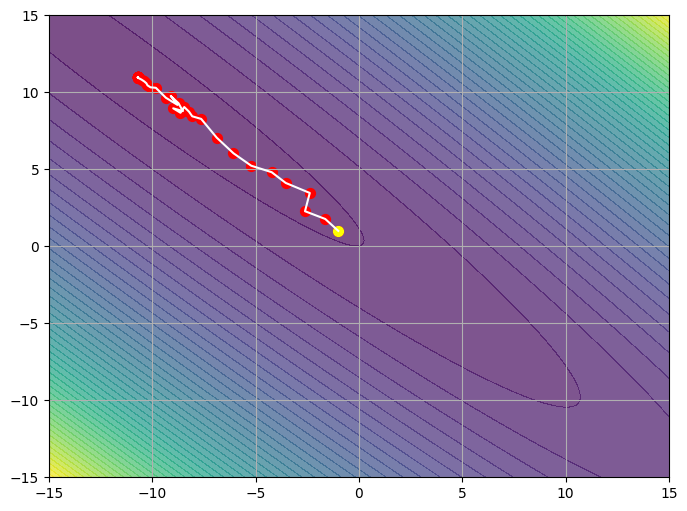

Точка минимума
x1 = -10.704
x2 = 10.963
Значение функции в этой точке: -1417.162
Итерации: 100
Вычисления функции: 409


In [19]:
x0=[-1,1]

x, f_x, iterations, func_evals, path =random_search_with_rejection(f,x0,alpha=1.0,max_iter=100000,epsilon=1e-6)
plot_rejection_random_search(f,path)

print("Точка минимума")
print(f"x1 = {x[0]:.3f}")
print(f"x2 = {x[1]:.3f}")
print(f"Значение функции в этой точке: {f_x:.3f}")
print(f"Итерации: {iterations}")
print(f"Вычисления функции: {func_evals}")

| Параметр | x1 | x2 | f(x1, x2) | Число итераций | Число вычислений функции |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Пакетный метод BFGS** | -10.704 | 10.963 | -1417.162 | - | - |
| **Адаптивный метод случайного поиска** | -10.704 | 10.963 | -1417.162 | 95 | 734 |
| **Mетод случайного поиска с возвратом** | -10.704 | 10.963 | -1417.162 | 100 | 409 |

## Оптимизация функции Химмельблау

$$f(x_1, x_2) = 100(x_1^2 + x_2 - 11)^2 + (x_1 + x_2^2 - 7)^2$$

In [14]:
def f_himmelblau(x):
    x1, x2 = x[0], x[1]
    return 100 * (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2

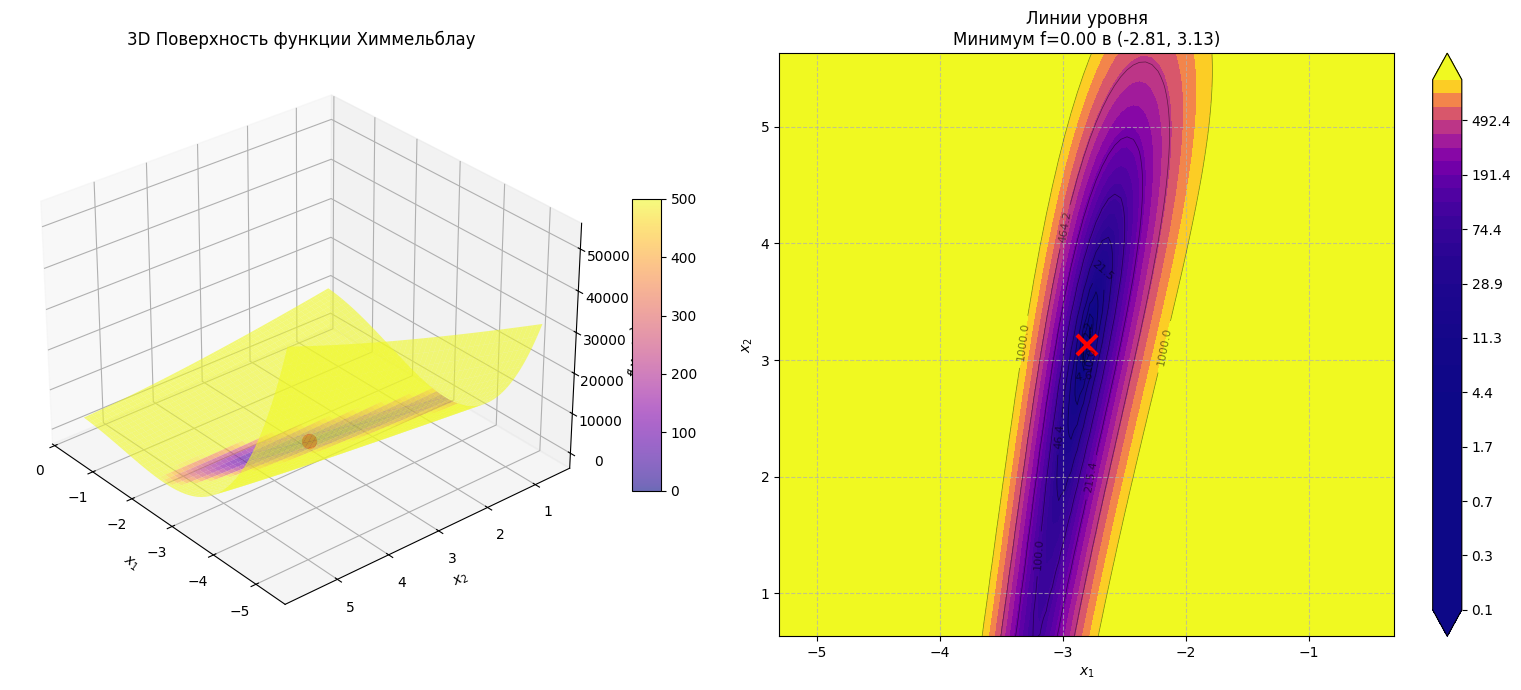

Точка минимума
x1 = -2.805
x2 = 3.131
Значение функции в этой точке: 0.000


In [8]:
x_min_arr = np.array([-2.805, 3.131])
f_min_val = f_himmelblau(x_min_arr)

buffer = 2.5
x1_range = np.linspace(x_min_arr[0] - buffer, x_min_arr[0] + buffer, 100)
x2_range = np.linspace(x_min_arr[1] - buffer, x_min_arr[1] + buffer, 100)
X1, X2 = np.meshgrid(x1_range, x2_range)
Z = f_himmelblau([X1, X2])
fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='plasma', edgecolor='none', alpha=0.6, 
                        norm=plt.Normalize(vmin=0, vmax=500))
ax1.scatter(x_min_arr[0], x_min_arr[1], f_min_val, color='red', s=100)
ax1.set_title('3D Поверхность функции Химмельблау')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.set_zlabel('$f(x_1, x_2)$')
ax1.view_init(elev=30, azim=140)
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
ax2 = fig.add_subplot(1, 2, 2)
levels = np.logspace(-1, 3, 40) 
contour_filled = ax2.contourf(X1, X2, Z, levels=levels, cmap='plasma', extend='both')
fig.colorbar(contour_filled, ax=ax2) 
contours = ax2.contour(X1, X2, Z, levels=np.logspace(0, 3, 10), colors='black', alpha=0.5, linewidths=0.5)
ax2.clabel(contours, inline=True, fontsize=8)
ax2.plot(x_min_arr[0], x_min_arr[1], 'rx', markersize=15, markeredgewidth=3)
ax2.set_title(f'Линии уровня\nМинимум f={f_min_val:.2f} в ({x_min_arr[0]:.2f}, {x_min_arr[1]:.2f})')
ax2.set_xlabel('$x_1$')
ax2.set_ylabel('$x_2$')
ax2.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

x0 = [-1.2, 1.0]
res = minimize(f_himmelblau, x0, method='BFGS')
print(f"Точка минимума\nx1 = {res.x[0]:.3f}\nx2 = {res.x[1]:.3f}")
print(f"Значение функции в этой точке: {res.fun:.3f}")

In [53]:
x0 = [-1, 1]

x,f_x,iteration,func_evals = adaptive_random_search(f_himmelblau, x0)

print("Точка минимума")
print(f"x1 = {x[0]:.4f}")
print(f"x2 = {x[1]:.4f}")
print(f"Значение функции в этой точке: {f_x:.4f}")
print(f"Итерации: {iteration}")
print(f"Вычисления функции: {func_evals}")

Точка минимума
x1 = -2.8051
x2 = 3.1313
Значение функции в этой точке: 0.0000
Итерации: 98
Вычисления функции: 747


##  Оптимизация функции Химмельблау адаптивным методом случайного поиска

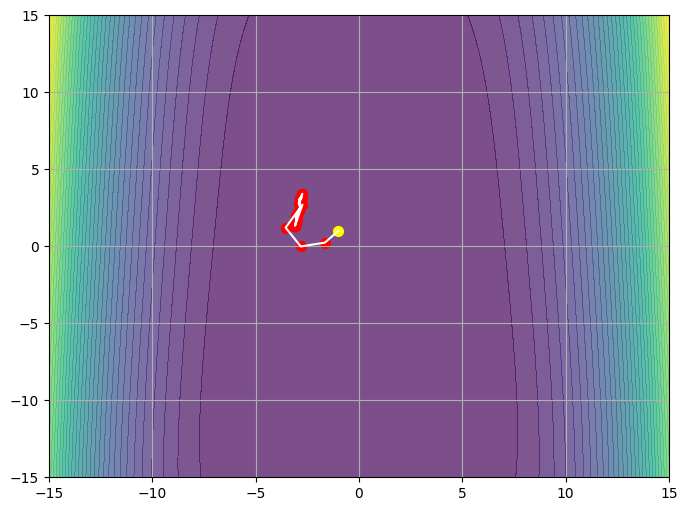

Точка минимума
x1 = -2.805
x2 = 3.131
Значение функции в этой точке: 0.000
Итерации: 110
Вычисления функции: 863


In [22]:
x0 = [-1, 1]

x, f_x, iteration, func_evals, path = adaptive_random_search(f_himmelblau, x0)

plot_trajectory(f_himmelblau,path)
print("Точка минимума")
print(f"x1 = {x[0]:.3f}")
print(f"x2 = {x[1]:.3f}")
print(f"Значение функции в этой точке: {f_x:.3f}")
print(f"Итерации: {iteration}")
print(f"Вычисления функции: {func_evals}")

##  Оптимизация функции Химмельблау методом случайного поиска с возвратом при неудачном шаге

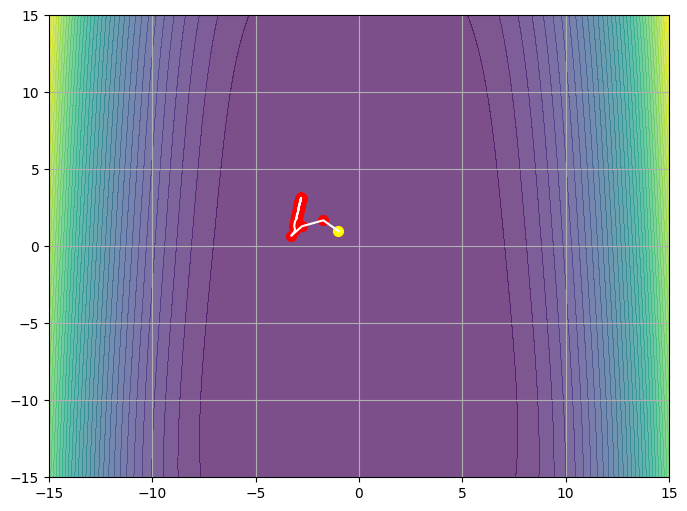

Точка минимума
x1 = -2.805
x2 = 3.131
Значение функции в этой точке: 0.000
Итерации: 290
Вычисления функции: 1059


In [23]:
x0=[-1,1]

x, f_x, iterations, func_evals, path =random_search_with_rejection(f_himmelblau,x0,alpha=1.0,max_iter=100000,epsilon=1e-6)
plot_rejection_random_search(f_himmelblau,path)

print("Точка минимума")
print(f"x1 = {x[0]:.3f}")
print(f"x2 = {x[1]:.3f}")
print(f"Значение функции в этой точке: {f_x:.3f}")
print(f"Итерации: {iterations}")
print(f"Вычисления функции: {func_evals}")

| Параметр | x1 | x2 | f(x1, x2) | Число итераций | Число вычислений функции |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Пакетный метод BFGS** | -2.805 | 3.131 | 0.000 | - | - |
| **Адаптивный метод случайного поиска** | -2.805 | 3.131 | 0.000 | 110 | 863 |
| **Mетод случайного поиска с возвратом** | -2.805 | 3.131 | 0.000 | 290 | 1059 |